# Angriness Predictor — Production Pipeline

This notebook documents the production ML pipeline for the **Angriness (Tilt) Predictor**. It uses an **Isolation Forest** anomaly detector to score chess games on a 1–5 tilt scale based on 22 features: behavioral (ACPL, blunders, consecutive losses), contextual (ELO, time control), and physiological (sleep, CO2, temperature, hydration, light).

The same logic runs headlessly via `run_pipeline.py` in CI. This notebook is the documented, visual version.

**Pipeline steps:**
1. **Gather** — Load and validate the training dataset
2. **Features** — Drop identifiers, encode categoricals, scale with StandardScaler
3. **Train** — Fit Isolation Forest, build percentile-based angriness bins (1–5)
4. **Evaluate** — Validate that high-angriness games correlate with worse play

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

TRAINER_DIR = Path.cwd().resolve().parent
RAW_DIR = TRAINER_DIR / "data" / "raw"
LEGACY_DIR = TRAINER_DIR / "data" / "legacy"
PLOT_DIR = Path.cwd() / "plots"
PLOT_DIR.mkdir(exist_ok=True)

print(f"Trainer root: {TRAINER_DIR}")
print(f"Raw data:     {RAW_DIR}")

## Step 1: Data Gathering

Load the training dataset and validate its structure. The dataset contains **25,249 games** from **13,726 players** across balanced ELO brackets (800–3400+), with 28 columns covering game performance, analysis metrics, and IoT sensor data.

Source: `data/raw/angriness_dataset_diverse.csv` — built by merging a friend's Lichess dataset with Kaggle chess game stats, enriched with synthetic IoT features (sleep, CO2, temperature, hydration, light).

In [2]:
DIVERSE_CSV = RAW_DIR / "angriness_dataset_diverse.csv"
ORIGINAL_CSV = LEGACY_DIR / "angriness_dataset.csv"

csv_path = DIVERSE_CSV if DIVERSE_CSV.exists() else ORIGINAL_CSV
if not csv_path.exists():
    raise FileNotFoundError(f"No dataset found. Expected {DIVERSE_CSV} or {ORIGINAL_CSV}")

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.name}")
print(f"  Shape: {df.shape}")
print(f"  Unique players: {df['username'].nunique()}")
df.head()

Loaded: angriness_dataset_diverse.csv
  Shape: (25249, 28)
  Unique players: 12301


,sleep_duration,consecutive_losses,awaken_duration,avg_tpm,move_cnt,inaccuracy_cnt_player,mistake_cnt_player,blunder_cnt_player,elo,elo_diff,...,elo_gap,move_cnt_player,avg_tpm_seconds_player,consecutive_losses_pregame,acpl_player,accuracy_player,avg_ppm,avg_celsius,water_intake_ml,avg_lux
0,7.80,0,1.58,13.6555,83,7.0,1.0,3.0,1011,8.0,...,8.0,41,27.6440,0,114.0,0.0,1313.91,22.10,1050,162.16
1,8.06,3,2.68,16.3612,65,0.0,1.0,0.0,1035,2.0,...,2.0,33,32.2266,3,35.0,19.3,1382.90,22.10,500,799.07
2,5.52,0,3.46,4.8241,74,4.0,4.0,2.0,1172,-134.0,...,-142.0,37,9.6482,0,91.0,0.0,1621.77,25.59,329,327.79
3,6.52,0,1.91,7.3261,75,2.0,1.0,1.0,1180,50.0,...,49.0,38,14.4594,0,56.0,5.8,1617.90,27.08,960,134.71
4,5.90,0,0.59,14.3966,59,2.0,0.0,1.0,1177,-126.0,...,-133.0,30,28.3133,0,28.0,27.3,1598.63,27.13,660,602.97


In [3]:
REQUIRED_COLUMNS = [
    "sleep_duration", "consecutive_losses", "awaken_duration", "avg_tpm",
    "move_cnt", "inaccuracy_cnt_player", "mistake_cnt_player",
    "blunder_cnt_player", "elo", "elo_diff", "game_id", "username",
    "created_at", "last_move_at", "player_color", "time_control_initial",
    "time_control_increment", "opponent_elo", "elo_gap", "move_cnt_player",
    "avg_tpm_seconds_player", "consecutive_losses_pregame", "acpl_player",
    "accuracy_player", "avg_ppm", "avg_celsius", "water_intake_ml", "avg_lux",
]

ANALYSIS_COLUMNS = [
    "acpl_player", "blunder_cnt_player", "mistake_cnt_player",
    "inaccuracy_cnt_player",
]

missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")
print(f"All {len(REQUIRED_COLUMNS)} required columns present.")

All 28 required columns present.


In [4]:
before = len(df)
df = df.dropna(subset=ANALYSIS_COLUMNS)
dropped = before - len(df)
print(f"Dropped {dropped} rows with null analysis -> {len(df)} remaining")

nulls = df[REQUIRED_COLUMNS].isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    print(f"\nRemaining nulls:\n{nulls.to_string()}")
else:
    print("Nulls: none")

Dropped 0 rows with null analysis -> 25249 remaining
Nulls: none


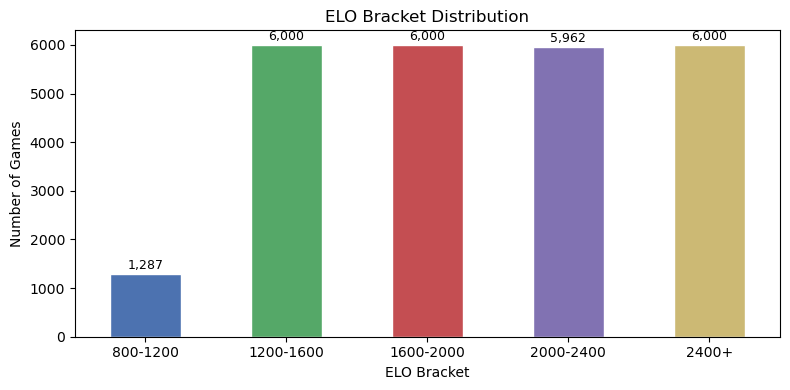

In [5]:
bins = [0, 1200, 1600, 2000, 2400, 5000]
labels = ["800-1200", "1200-1600", "1600-2000", "2000-2400", "2400+"]
brackets = pd.cut(df["elo"], bins=bins, labels=labels)
counts = brackets.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot.bar(ax=ax, color=["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"], edgecolor="white")
ax.set_title("ELO Bracket Distribution")
ax.set_xlabel("ELO Bracket")
ax.set_ylabel("Number of Games")
for i, v in enumerate(counts):
    ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=9)
ax.set_xticklabels(labels, rotation=0)
fig.tight_layout()
fig.savefig(PLOT_DIR / "elo_distribution.png", dpi=150)
plt.show()

In [ ]:
print(f"Validated: {len(df)} rows, {len(df.columns)} columns ready for feature engineering")

## Step 2: Feature Engineering

Transform the raw dataset into 22 scaled features for the model:

| Group | Features | Count |
|---|---|---|
| **Behavioral** | consecutive_losses_pregame, avg_tpm_seconds_player, blunder/mistake/inaccuracy counts, acpl_player, accuracy_player | 7 |
| **Contextual** | elo, elo_diff, opponent_elo, elo_gap, time_control_initial/increment, move_cnt, move_cnt_player | 8 |
| **Physiological** | sleep_duration, awaken_duration, avg_ppm, avg_celsius, water_intake_ml, avg_lux | 6 |
| **Categorical** | is_black (encoded from player_color) | 1 |

**Dropped**: identifiers (`game_id`, `username`, timestamps) and redundant columns (`consecutive_losses` = alias of `consecutive_losses_pregame`, `avg_tpm` ~ `avg_tpm_seconds_player`).

In [ ]:
DROP_IDENTIFIERS = ["game_id", "username", "created_at", "last_move_at"]
DROP_REDUNDANT = ["consecutive_losses", "avg_tpm"]

FEATURE_ORDER = [
    "consecutive_losses_pregame",
    "avg_tpm_seconds_player",
    "blunder_cnt_player",
    "mistake_cnt_player",
    "inaccuracy_cnt_player",
    "acpl_player",
    "accuracy_player",
    "elo",
    "elo_diff",
    "opponent_elo",
    "elo_gap",
    "time_control_initial",
    "time_control_increment",
    "move_cnt",
    "move_cnt_player",
    "sleep_duration",
    "awaken_duration",
    "avg_ppm",
    "avg_celsius",
    "water_intake_ml",
    "avg_lux",
    "is_black",
]

df_feat = df.copy()

to_drop = [c for c in DROP_IDENTIFIERS + DROP_REDUNDANT if c in df_feat.columns]
df_feat.drop(columns=to_drop, inplace=True)
print(f"After dropping identifiers/redundant: {df_feat.shape}")

if "player_color" in df_feat.columns:
    df_feat["is_black"] = (df_feat["player_color"] == "black").astype(int)
    df_feat.drop(columns=["player_color"], inplace=True)
    print(f"Encoded player_color -> is_black (black={df_feat['is_black'].sum()}, white={(df_feat['is_black'] == 0).sum()})")

for col in df_feat.select_dtypes(include=[np.number]).columns:
    if df_feat[col].isnull().any():
        df_feat[col] = df_feat[col].fillna(df_feat[col].median())

print(f"Nulls after median fill: {df_feat.isnull().sum().sum()}")

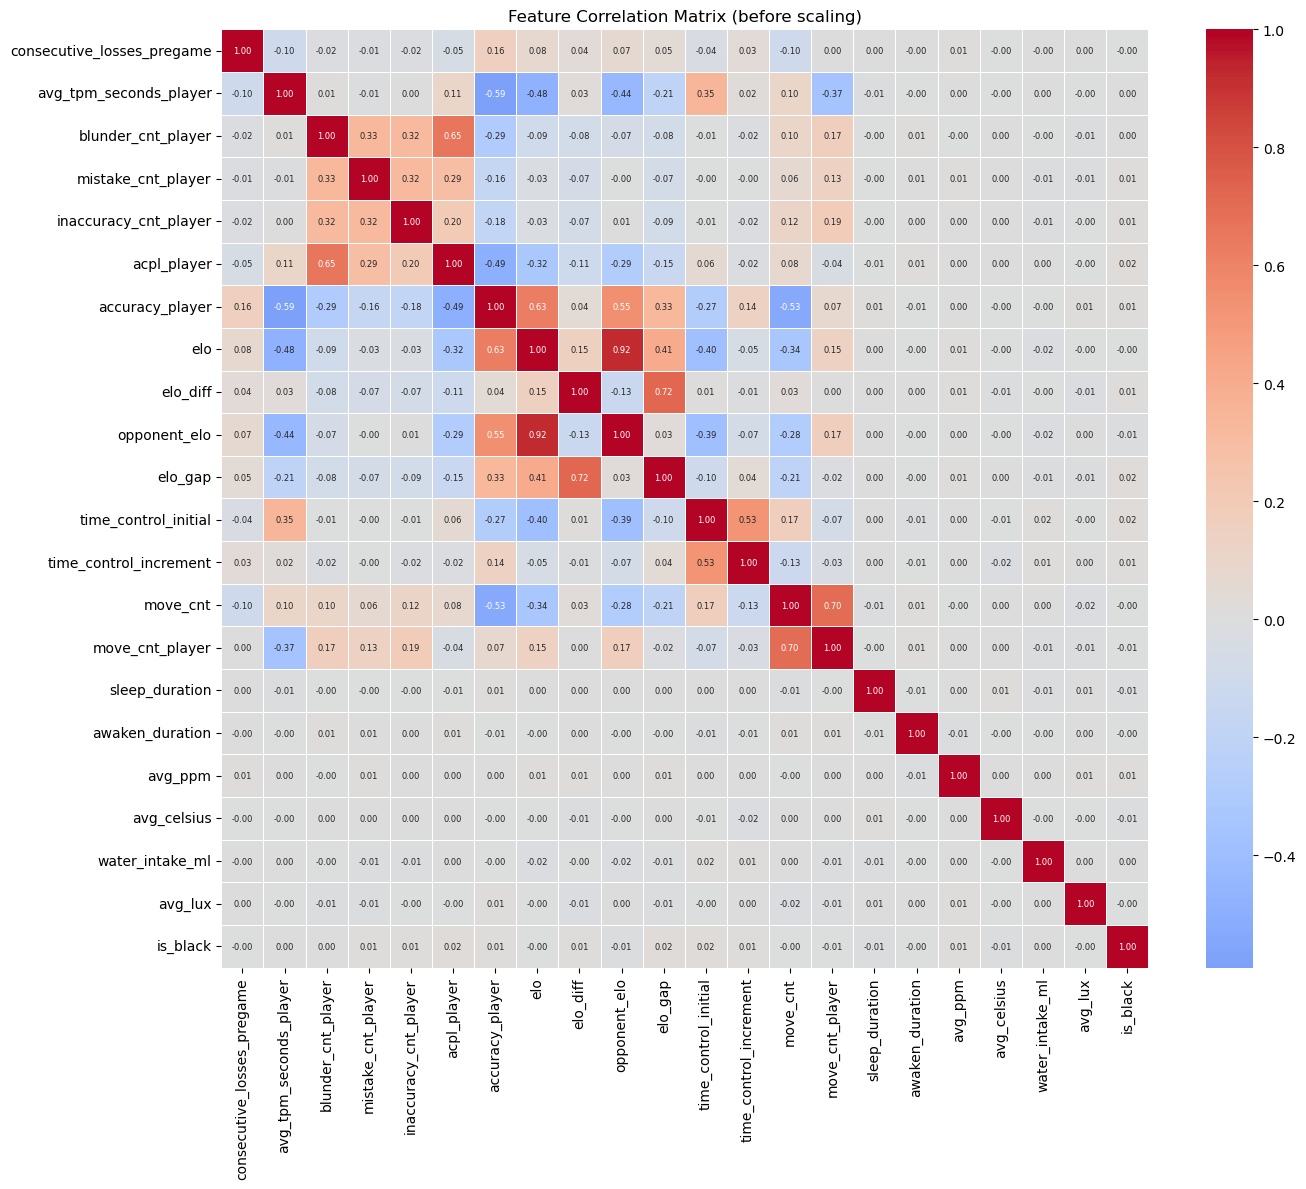

In [8]:
available = [c for c in FEATURE_ORDER if c in df_feat.columns]

corr = df_feat[available].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 6}, linewidths=0.5)
ax.set_title("Feature Correlation Matrix (before scaling)")
fig.tight_layout()
fig.savefig(PLOT_DIR / "pipeline_correlation.png", dpi=150)
plt.show()

In [ ]:
df_features = df_feat[available].copy()

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_features),
    columns=available,
)

print(f"Scaled: {df_scaled.shape}")
print(f"\nFeatures ({len(available)}):")
for i, col in enumerate(available, 1):
    print(f"  {i:2d}. {col}")

## Step 3: Training

Train an **Isolation Forest** anomaly detector. The model assigns each game an anomaly score via `decision_function()` — more negative scores indicate more anomalous (tilted) games.

**Why Isolation Forest over K-Means?** During exploration, K-Means (k=2, silhouette=0.168) split games by time-per-move, not tilt behavior. Isolation Forest anomalies showed 4.7x higher consecutive losses, 2x more blunders, and 44% higher ACPL — exactly the tilt signal we want.

**Hyperparameters** (selected via grid search in `experiment.ipynb`):
- `contamination=0.03` — 3% of games flagged as anomalies (most extreme tilt)
- `n_estimators=200` — number of trees
- `max_features=0.75` — feature subsampling per tree

**Angriness scale (1–5)**: The continuous anomaly scores are binned into 5 levels using percentile edges at `[p0, p10, p35, p65, p90, p100]`. Level 5 (most anomalous) = most tilted, Level 1 (least anomalous) = calmest.

In [ ]:
model = IsolationForest(
    contamination=0.03,
    n_estimators=200,
    max_features=0.75,
    random_state=42,
)

model.fit(df_scaled.values)

scores = model.decision_function(df_scaled.values)
labels = model.predict(df_scaled.values)
n_anomalies = (labels == -1).sum()
print(f"Trained on: {df_scaled.shape}")
print(f"Anomalies: {n_anomalies} / {len(df_scaled)} ({n_anomalies / len(df_scaled):.1%})")

In [11]:
PERCENTILE_EDGES = [0, 10, 35, 65, 90, 100]


def score_to_angriness(score: float, bin_edges: list[float]) -> int:
    for i in range(len(bin_edges) - 1):
        if score <= bin_edges[i + 1]:
            return 5 - i
    return 1


bin_edges = [float(np.percentile(scores, p)) for p in PERCENTILE_EDGES]
print(f"Percentiles: {PERCENTILE_EDGES}")
print(f"Bin edges:   {[round(e, 4) for e in bin_edges]}")

angriness_levels = np.array([score_to_angriness(s, bin_edges) for s in scores])

Percentiles: [0, 10, 35, 65, 90, 100]
Bin edges:   [-0.1345, 0.0231, 0.0545, 0.0783, 0.1008, 0.1356]


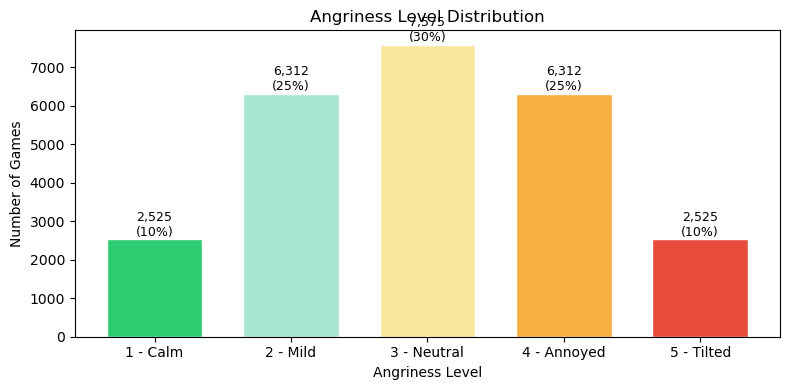

In [12]:
level_counts = pd.Series(angriness_levels).value_counts().sort_index()
level_labels = {1: "Calm", 2: "Mild", 3: "Neutral", 4: "Annoyed", 5: "Tilted"}
colors = ["#2ecc71", "#a8e6cf", "#f9e79f", "#f5b041", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(level_counts.index, level_counts.values, color=colors, edgecolor="white", width=0.7)
for bar, count in zip(bars, level_counts.values):
    pct = count / len(angriness_levels) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f"{count:,}\n({pct:.0f}%)", ha="center", fontsize=9)
ax.set_xticks(level_counts.index)
ax.set_xticklabels([f"{lvl} - {level_labels[lvl]}" for lvl in level_counts.index])
ax.set_xlabel("Angriness Level")
ax.set_ylabel("Number of Games")
ax.set_title("Angriness Level Distribution")
fig.tight_layout()
fig.savefig(PLOT_DIR / "angriness_distribution.png", dpi=150)
plt.show()

In [ ]:
tilt_cols = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
raw = df_feat.copy()
raw["_angriness"] = angriness_levels

sanity = raw.groupby("_angriness")[tilt_cols].mean().round(2)
sanity.index.name = "Angriness"
sanity.columns = ["ACPL", "Blunders", "Consecutive Losses"]
print("Sanity check — unscaled feature means by angriness level:\n")
sanity

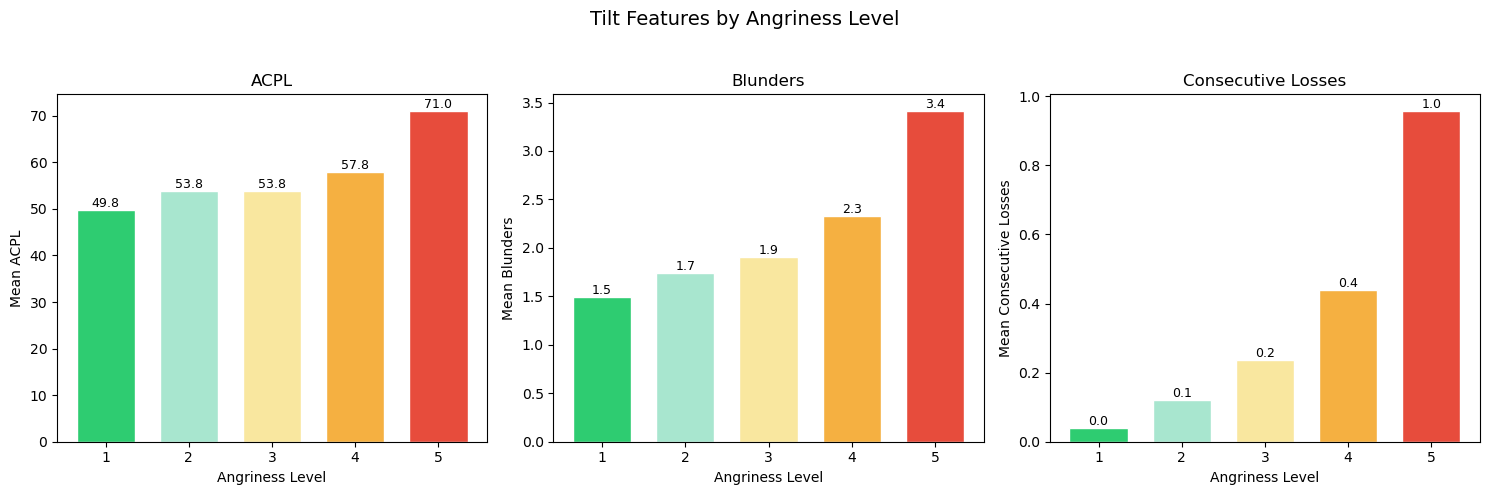

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, [("acpl_player", "ACPL"), ("blunder_cnt_player", "Blunders"), ("consecutive_losses_pregame", "Consecutive Losses")]):
    means = raw.groupby("_angriness")[col].mean()
    bars = ax.bar(means.index, means.values, color=colors, edgecolor="white", width=0.7)
    ax.set_xlabel("Angriness Level")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(label)
    ax.set_xticks(means.index)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Tilt Features by Angriness Level", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(PLOT_DIR / "sanity_check_by_level.png", dpi=150)
plt.show()

In [ ]:
metrics = {
    "model_type": "Isolation Forest",
    "contamination": 0.03,
    "n_estimators": 200,
    "max_features": 0.75,
    "n_rows": len(df_scaled),
    "n_features": len(df_scaled.columns),
    "n_anomalies": int(n_anomalies),
    "anomaly_rate": round(n_anomalies / len(df_scaled), 4),
    "angriness_distribution": {
        str(level): int((angriness_levels == level).sum())
        for level in range(1, 6)
    },
}

print("Training metrics:\n")
print(json.dumps(metrics, indent=2))
print("\nTo generate model artifacts, run: python run_pipeline.py")

## Step 4: Evaluation

Validate that the angriness scale makes sense: games rated as tilted (levels 4–5) should have **higher** ACPL, more blunders, and more consecutive losses than calm games (levels 1–2). If these checks fail, the model is not capturing tilt behavior.

In [16]:
TILT_FEATURES = [
    "acpl_player", "blunder_cnt_player", "mistake_cnt_player",
    "inaccuracy_cnt_player", "consecutive_losses_pregame",
    "accuracy_player", "avg_tpm_seconds_player",
]

raw["_score"] = scores
available_tilt = [c for c in TILT_FEATURES if c in raw.columns]

per_level = {}
for level in range(1, 6):
    mask = raw["_angriness"] == level
    subset = raw.loc[mask]
    stats = {"count": int(mask.sum())}
    for col in available_tilt:
        stats[f"mean_{col}"] = round(float(subset[col].mean()), 2) if len(subset) > 0 else None
    stats["mean_score"] = round(float(subset["_score"].mean()), 4) if len(subset) > 0 else None
    per_level[str(level)] = stats

pd.DataFrame(per_level).T

,count,mean_acpl_player,mean_blunder_cnt_player,mean_mistake_cnt_player,mean_inaccuracy_cnt_player,mean_consecutive_losses_pregame,mean_accuracy_player,mean_avg_tpm_seconds_player,mean_score
1,2525.0,49.78,1.49,0.99,2.72,0.04,14.62,19.05,0.1094
2,6312.0,53.81,1.74,1.13,3.03,0.12,18.64,19.08,0.0889
3,7575.0,53.85,1.90,1.27,3.17,0.24,37.00,15.49,0.0667
4,6312.0,57.84,2.33,1.53,3.40,0.44,50.59,12.10,0.0413
5,2525.0,71.04,3.41,2.05,4.04,0.96,58.34,10.55,0.0041


In [17]:
calm = raw[raw["_angriness"].isin([1, 2])]
tilted = raw[raw["_angriness"].isin([4, 5])]

checks = {
    "ACPL higher when tilted": (
        tilted["acpl_player"].mean() > calm["acpl_player"].mean()
    ),
    "Blunders higher when tilted": (
        tilted["blunder_cnt_player"].mean() > calm["blunder_cnt_player"].mean()
    ),
    "Consecutive losses higher when tilted": (
        tilted["consecutive_losses_pregame"].mean() > calm["consecutive_losses_pregame"].mean()
    ),
}

all_pass = all(checks.values())
print(f"Validation: {'PASS' if all_pass else 'FAIL'}\n")
for check, result in checks.items():
    print(f"  {'PASS' if result else 'FAIL'} — {check}")

Validation: PASS

  PASS — ACPL higher when tilted
  PASS — Blunders higher when tilted
  PASS — Consecutive losses higher when tilted


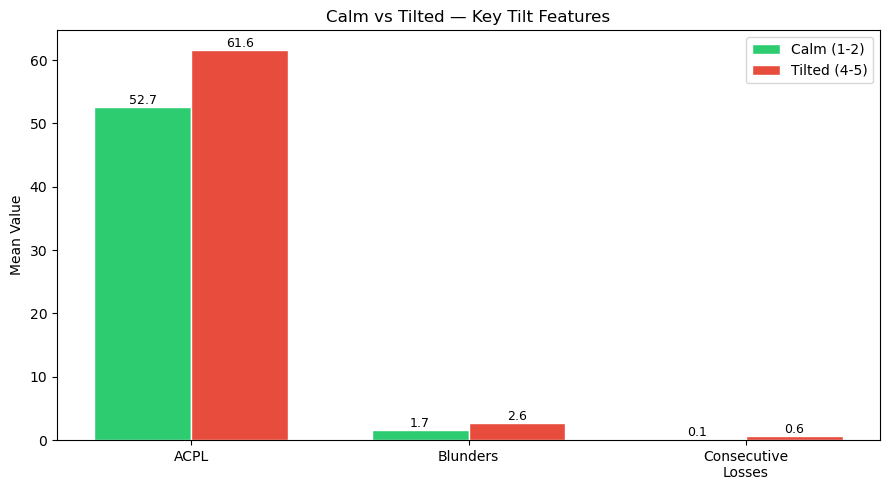

In [18]:
compare_cols = ["acpl_player", "blunder_cnt_player", "consecutive_losses_pregame"]
compare_labels = ["ACPL", "Blunders", "Consecutive\nLosses"]

calm_means = calm[compare_cols].mean()
tilted_means = tilted[compare_cols].mean()

x = np.arange(len(compare_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, calm_means.values, width, label="Calm (1-2)", color="#2ecc71", edgecolor="white")
bars2 = ax.bar(x + width / 2, tilted_means.values, width, label="Tilted (4-5)", color="#e74c3c", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(compare_labels)
ax.set_ylabel("Mean Value")
ax.set_title("Calm vs Tilted — Key Tilt Features")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "calm_vs_tilted.png", dpi=150)
plt.show()

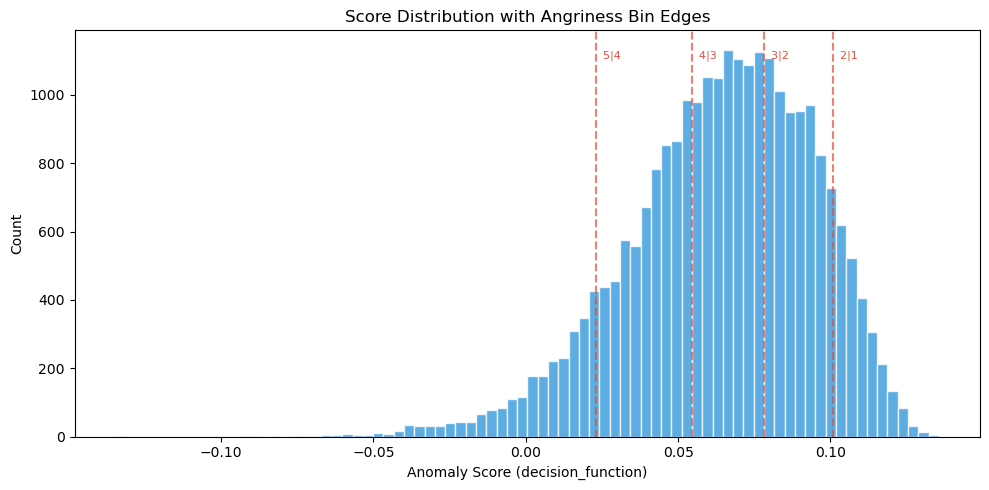

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores, bins=80, edgecolor="white", alpha=0.8, color="#3498db")
for i, edge in enumerate(bin_edges[1:-1]):
    ax.axvline(x=edge, color="#e74c3c", linestyle="--", alpha=0.7)
    ax.text(edge, ax.get_ylim()[1] * 0.95, f"  {5 - i}|{4 - i}",
            fontsize=8, color="#e74c3c", va="top")
ax.set_xlabel("Anomaly Score (decision_function)")
ax.set_ylabel("Count")
ax.set_title("Score Distribution with Angriness Bin Edges")
fig.tight_layout()
fig.savefig(PLOT_DIR / "score_distribution.png", dpi=150)
plt.show()

In [ ]:
print(f"Pipeline walkthrough complete. All validations {'PASSED' if all_pass else 'FAILED'}.")
print(f"\nScore stats:")
print(f"  min:  {scores.min():.4f}")
print(f"  max:  {scores.max():.4f}")
print(f"  mean: {scores.mean():.4f}")
print(f"  std:  {scores.std():.4f}")
print(f"\nTo generate production artifacts (models/*.pkl, models/*.json),")
print(f"run from trainer root:  python run_pipeline.py")